In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('data/superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,MONTH ORDERED,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,SubCategory,tegProduct Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,November,Nov-16,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,262,2,0.00,41.9136
1,2,CA-2016-152156,November,Nov-16,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",732,3,0.00,219.5820
2,3,CA-2016-138688,June,Jun-16,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,15,2,0.00,6.8714
3,4,US-2015-108966,October,Oct-15,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,958,5,0.45,-383.0310
4,5,US-2015-108966,October,Oct-15,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22,2,0.20,2.5164


In [5]:
print(df.head())

   Row ID        Order ID MONTH  ORDERED Order Date   Ship Date  \
0       1  CA-2016-152156       November     Nov-16  11/11/2016   
1       2  CA-2016-152156       November     Nov-16  11/11/2016   
2       3  CA-2016-138688           June     Jun-16   6/16/2016   
3       4  US-2015-108966        October     Oct-15  10/18/2015   
4       5  US-2015-108966        October     Oct-15  10/18/2015   

        Ship Mode Customer ID    Customer Name    Segment        Country  ...  \
0    Second Class    CG-12520      Claire Gute   Consumer  United States  ...   
1    Second Class    CG-12520      Claire Gute   Consumer  United States  ...   
2    Second Class    DV-13045  Darrin Van Huff  Corporate  United States  ...   
3  Standard Class    SO-20335   Sean O'Donnell   Consumer  United States  ...   
4  Standard Class    SO-20335   Sean O'Donnell   Consumer  United States  ...   

  Postal Code Region       Product ID         Category SubCategory  \
0       42420  South  FUR-BO-10001798   

In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Row ID           9994 non-null   int64  
 1   Order ID         9994 non-null   str    
 2   MONTH  ORDERED   9994 non-null   str    
 3   Order Date       9994 non-null   str    
 4   Ship Date        9994 non-null   str    
 5   Ship Mode        9994 non-null   str    
 6   Customer ID      9994 non-null   str    
 7   Customer Name    9994 non-null   str    
 8   Segment          9994 non-null   str    
 9   Country          9994 non-null   str    
 10  City             9994 non-null   str    
 11  State            9994 non-null   str    
 12  Postal Code      9994 non-null   int64  
 13  Region           9994 non-null   str    
 14  Product ID       9994 non-null   str    
 15  Category         9994 non-null   str    
 16  SubCategory      9994 non-null   str    
 17  tegProduct Name  9994 non

In [7]:
print(df.isnull().sum())

Row ID             0
Order ID           0
MONTH  ORDERED     0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country            0
City               0
State              0
Postal Code        0
Region             0
Product ID         0
Category           0
SubCategory        0
tegProduct Name    0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64


In [8]:
sales_by_region = df.groupby('Region')['Sales'].sum()
print(sales_by_region)

Region
Central    501256
East       678834
South      391750
West       725514
Name: Sales, dtype: int64


In [9]:
profit_by_category = df.groupby('Category')['Profit'].sum()
print(profit_by_category)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


In [10]:
top_customers =df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer Name
Sean Miller           25042
Tamara Chand          19050
Raymond Buch          15117
Tom Ashbrook          14596
Adrian Barton         14476
Ken Lonsdale          14175
Sanjit Chand          14145
Hunter Lopez          12875
Sanjit Engle          12209
Christopher Conant    12128
Name: Sales, dtype: int64


In [13]:
loss_orders =df[df['Profit']<0]
print(loss_orders.head())

    Row ID        Order ID MONTH  ORDERED Order Date   Ship Date  \
3        4  US-2015-108966        October     Oct-15  10/18/2015   
14      15  US-2015-118983       November     Nov-15  11/26/2015   
15      16  US-2015-118983       November     Nov-15  11/26/2015   
23      24  US-2017-156909           July     Jul-17   7/18/2017   
27      28  US-2015-150630      September     Sep-15   9/21/2015   

         Ship Mode Customer ID    Customer Name      Segment        Country  \
3   Standard Class    SO-20335   Sean O'Donnell     Consumer  United States   
14  Standard Class    HP-14815    Harold Pawlan  Home Office  United States   
15  Standard Class    HP-14815    Harold Pawlan  Home Office  United States   
23    Second Class    SF-20065  Sandra Flanagan     Consumer  United States   
27  Standard Class    TB-21520  Tracy Blumstein     Consumer  United States   

    ... Postal Code   Region       Product ID         Category SubCategory  \
3   ...       33311    South  FUR-TA-1

In [19]:
pivot =pd.pivot_table(df, values ='Sales',index='Region',columns='Category',aggfunc='sum')
print(pivot)

Category  Furniture  Office Supplies  Technology
Region                                          
Central      163789           167035      170432
East         208291           205549      264994
South        117306           125662      148782
West         252620           220881      252013


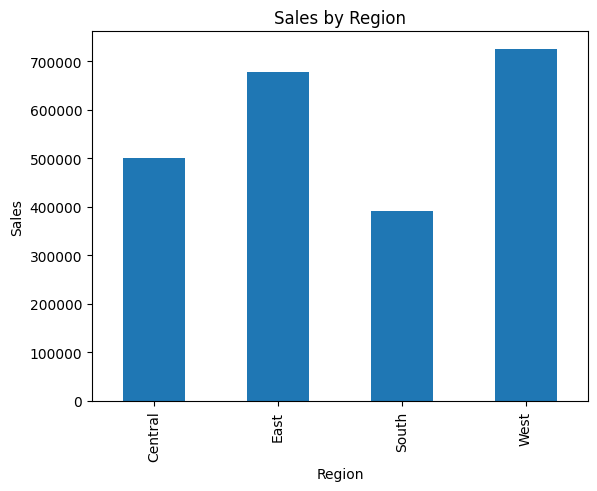

In [20]:
sales_by_region.plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.show()